# El Qang (qg): avances §20–§74, reproducibles en Colab

Este notebook es la continuación de `qang_verificado.ipynb` (secciones 1–19 de `RESEARCH_NOTES.md`). Reúne los resultados posteriores en versiones **rápidas**: cada celda llama al script del repositorio que genera el resultado completo (carpeta `examples/`), con menos repeticiones para que todo corra en pocos minutos. Los números completos, con más semillas, están en `RESEARCH_NOTES.md` y fijados por los tests del repositorio.

Cada sección termina con una **Lectura** que dice a favor de qué gana qg y a favor de qué no. Resumen de antemano: qg mejora a la computación cuántica ruidosa frente a la misma computación sin qg (diagnóstico, filtros, reglas de decisión); **no** muestra ventaja cuántica sobre los métodos clásicos, y todo es simulación (modelos de ruido de IBM e IonQ), no hardware real.

**Contenido**

1. Química: el testigo $\overline{qg}_Z = 1 - 2N/n$ y el filtro (H₂) — §21
2. ¿Qué ruido arregla cada método? Filtro qg vs ZNE — §24
3. Materiales: dinámica de Hubbard con filtros de número y de espín — §29
4. Optimización con restricción: QAOA "exactamente K" — §30
5. Caracterización del qubit: temperatura vs error de lectura — §31
6. Corrección de errores: código de Leung y la regla T2 > T1 — §32
7. El síndrome como testigo continuo — §33
8. Coherencia: la brecha de entropía y una cota qg — §34
9. Estimación con pocos disparos — §35–§37
10. Barren plateaus: coste local qg vs global — §23
11. Simulador ruidoso de IonQ (resultados grabados) — §38–§39
12. Ruido de disparos en registros — §45
13. Máquinas de Boltzmann restringidas — §47
14. Errores coherentes: ZNE no los ve, el filtro sí — §48
15. Química con chequeos en bases rotadas (resultados grabados) — §50–§55
16. Baterías cuánticas y pares de Bell — §56–§57
17. Metrología con estados GHZ — §58
18. Código de superficie y T1 — §59, §64
19. Cadena XXZ — §60–§61
20. ¿Sombras clásicas o medir directo? — §62
21. Grover con ruido: un límite de qg — §63
22. El rango del arccos se elimina con un signo — §65
23. Ley de Gauss en una teoría de gauge en red — §66
24. ¿Filtro o ZNE según los disparos? — §67
25. La exposición del sector: predecir sin ruido cuánto T1 deja pasar el filtro — §68
26. Espín total S² en química (resultados grabados) — §69
27. La prueba del qutrit: marcas de fuga — §70, §70b
28. Una regla bayesiana para la marca de fuga, y distancia 5 — §71
29. Dónde queda un transmón real — §72
30. Qubits de borrado: la regla (1 − h) — §73–§74
31. Resumen honesto

In [1]:
# Instalación (Colab). En una copia local del repositorio basta con ejecutar desde la carpeta notebooks/.
import os, sys, subprocess
if not os.path.exists("qang") and not os.path.exists("../examples"):
    subprocess.run(["git", "clone", "-q", "https://github.com/Viny2030/qang"], check=True)
ROOT = "qang" if os.path.exists("qang") else ".."
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ROOT,
                "qiskit", "qiskit-aer", "qiskit-ibm-runtime", "scipy", "matplotlib", "pymatching"], check=True)
sys.path.insert(0, os.path.abspath(os.path.join(ROOT, "examples")))
sys.path.insert(0, os.path.abspath(ROOT))
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
EX = os.path.abspath(os.path.join(ROOT, "examples"))
print("listo: ejemplos en", EX.replace(os.path.expanduser("~"), "~"))

listo: ejemplos en /tmp/qnow/examples


## 1. Química: el testigo y el filtro qg en H₂ (§21)

En el mapeo de Jordan–Wigner, un circuito que conserva el número de electrones $N$ tiene $\overline{qg}_Z = 1 - 2N/n$ fijo **para cualquier parámetro** (0 para H₂: 2 electrones en 4 qubits). Entonces:

* **testigo:** si $\overline{qg}_Z$ medido se aleja de 0, el hardware está perdiendo o ganando electrones (sobre todo T1);
* **filtro:** se descartan los disparos con peso de Hamming $\ne N$ (verificación de simetría, técnica conocida; lo nuevo es leerla como testigo).

Se corre el estado VQE exacto de H₂ en el modelo de ruido calibrado `fake_brisbane`, con y sin una espera antes de medir (que amplifica T1).

In [2]:
import chemistry_qg_symmetry_witness as CH
print(f"Hartree-Fock (clásico): {1e3*(CH.HF_ENERGY-CH.FCI_ENERGY):.1f} mHa por encima de FCI")
for delay in (0, 50):
    r = CH.run_noisy(delay, seed=11)
    e = lambda k: 1e3 * (r[k] - CH.FCI_ENERGY)
    print(f"espera {delay:2d} us: qg_Z medio {r['mean_qg_z']:+.3f}, disparos que conserva el filtro {r['kept_fraction']:.2f} | "
          f"crudo {e('raw'):6.1f}, +lectura {e('readout'):6.1f}, +lectura +filtro qg {e('readout_qg_filter'):6.1f} mHa")

Hartree-Fock (clásico): 20.3 mHa por encima de FCI


espera  0 us: qg_Z medio +0.011, disparos que conserva el filtro 0.90 | crudo   77.3, +lectura   20.4, +lectura +filtro qg    6.0 mHa


espera 50 us: qg_Z medio +0.123, disparos que conserva el filtro 0.72 | crudo  232.8, +lectura  189.2, +lectura +filtro qg   29.3 mHa


**Lectura.** El testigo sube con T1 (de ~0.01 a ~0.12) en proporción a los disparos que perdieron un electrón, y el filtro baja el error por debajo de Hartree–Fock sin circuitos extra (~6 mHa contra 20.3, sin espera). En contra: FCI es exacto y trivial a este tamaño; en LiH con 60 compuertas de dos qubits (§21) el filtro deja de ayudar y el testigo lo avisa (se mueve hacia 0, no hacia +1).

## 2. ¿Qué ruido arregla cada método? (§24)

Mismo H₂, con ruido controlado en cada CX. Se compara el filtro qg con la extrapolación a ruido cero (ZNE: plegar cada CX ×3, ×5 y extrapolar) y con ambos.

In [3]:
import error_mitigation_qg_vs_zne as EM
for noise in (("T1", 0.10), ("dephasing", 0.10), ("depolarizing", 0.10)):
    r = EM.error_table(noise, seeds=range(11, 14))
    print(f"{noise[0]:12s} qg_Z {r['mean_qg_z']:+.3f} conserva {r['kept_fraction']:.2f} | " +
          "  ".join(f"{m} {r[m][0]:6.1f}" for m in EM.METHODS) + "  (mHa)")

T1           qg_Z +0.099 conserva 0.81 | raw  130.6  qg_filter    9.1  zne   -4.6  zne_qg    2.4  (mHa)


dephasing    qg_Z +0.000 conserva 1.00 | raw   11.8  qg_filter   11.8  zne    5.5  zne_qg    5.5  (mHa)


depolarizing qg_Z +0.021 conserva 0.86 | raw  193.9  qg_filter   82.8  zne   13.1  zne_qg   -1.3  (mHa)


**Lectura.** El testigo predice si el filtro sirve: con desfase no se mueve y el filtro no cambia nada (solo ZNE ayuda); con T1 se mueve y el filtro quita ~95% del error gratis. Los métodos se complementan. Con pocos disparos (2000, §39) ZNE se vuelve muy variable y el filtro gana en error típico.

## 3. Materiales: dinámica de Hubbard 1D (§29)

4 sitios (8 qubits), evolución Trotter desde una onda de densidad de carga. El Hamiltoniano conserva $N_\uparrow$ y $N_\downarrow$ por separado: dos testigos y dos filtros, y **todos** los observables (doble ocupación, desbalance de carga) están en la base Z, así que el filtro actúa sobre todos. Dispositivo genérico todos-con-todos (ruido despolarizante).

pasos 1: fuga de espín 0.004 | doble ocupación, |error|: raw 0.008  n_filter 0.003  spin_filter 0.002  zne 0.001  zne_spin 0.001
pasos 2: fuga de espín 0.011 | doble ocupación, |error|: raw 0.002  n_filter 0.001  spin_filter 0.001  zne 0.002  zne_spin 0.003
pasos 4: fuga de espín 0.028 | doble ocupación, |error|: raw 0.017  n_filter 0.010  spin_filter 0.007  zne 0.001  zne_spin 0.002


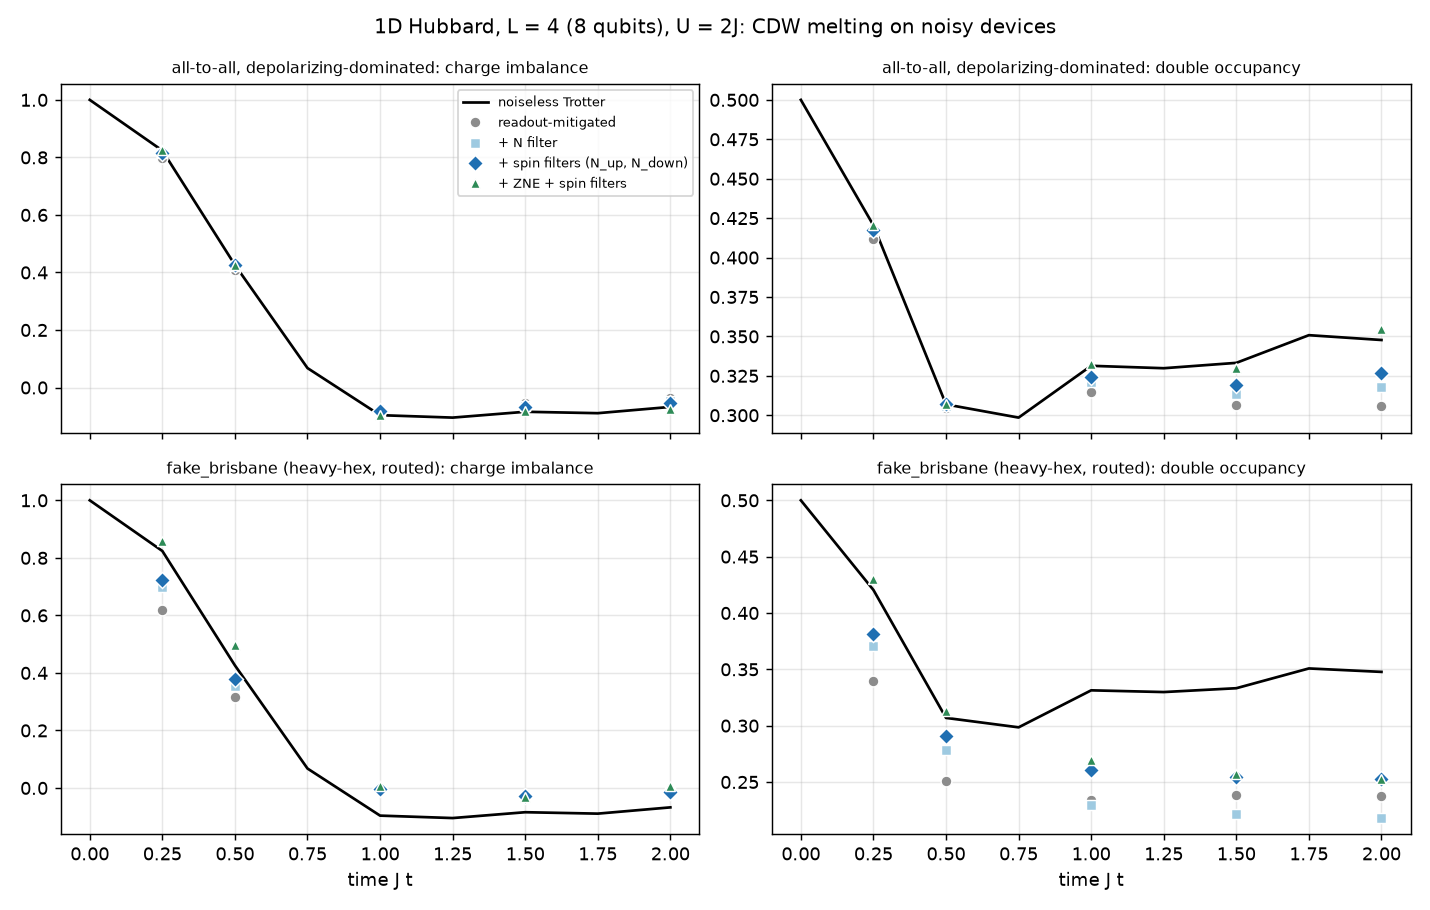

In [4]:
import hubbard_trotter_qg_filters as HB
t = HB.error_table((1, 2, 4), seeds=(11, 12), device="all_to_all")
for s, e in t.items():
    print(f"pasos {s}: fuga de espín {e['spin_leak']:.3f} | doble ocupación, |error|: " +
          "  ".join(f"{m} {e[('double_occ', m)][0]:.3f}" for m in HB.METHODS))
display(Image(os.path.join(EX, "hubbard_trotter_qg_filters.png"), width=900))

**Lectura.** Los filtros bajan el error y el de espín suma cuando la fuga de espín crece con la profundidad; con 20.000 disparos, ZNE (solo o con los filtros) da el menor error. En `fake_brisbane` (figura, abajo) mover información entre qubits crea mucha fuga de espín y desde ~190 compuertas todo cae al piso de ruido. En contra: 8 qubits se calculan exacto en una computadora común.

## 4. QAOA con "exactamente K" (§30)

Máximo K-vertex cover (elegir exactamente 3 de 8 nodos). La restricción es $\overline{qg}_Z = 1 - 2K/n = 0.25$: el mismo testigo/filtro. Variantes: QAOA estándar con penalidad, arranque qg de presupuesto, arranque en caliente (LP) y mezclador XY (conserva la restricción). Ángulos pre-optimizados en `examples/data/qaoa_k_angles.json`.

In [5]:
import ionq_sim_hubbard_qaoa as IQ
s = IQ.summarize_qaoa(IQ.qaoa(None, None, "local", p=1))
print(f"adivinar una solución válida: P(óptimo) = {s['random_feasible']:.3f}")
for v in ("standard", "qg_budget", "qg_warm", "xy"):
    print(f"{v:10s} P(óptimo) sin ruido {s[v]['ideal']:.3f} | con ruido {s[v]['noisy']:.3f} -> con filtro qg {s[v]['noisy_f']:.3f}")

adivinar una solución válida: P(óptimo) = 0.096
standard   P(óptimo) sin ruido 0.053 | con ruido 0.046 -> con filtro qg 0.104
qg_budget  P(óptimo) sin ruido 0.066 | con ruido 0.054 -> con filtro qg 0.099
qg_warm    P(óptimo) sin ruido 0.195 | con ruido 0.164 -> con filtro qg 0.316
xy         P(óptimo) sin ruido 0.346 | con ruido 0.145 -> con filtro qg 0.269


**Lectura.** El filtro duplica el éxito del mezclador XY (y lo mismo con los modelos de ruido de IonQ, §38). El QAOA estándar con penalidad, filtrado, queda al nivel de adivinar. En contra: el algoritmo greedy clásico llega al 98.5% del óptimo y ninguna variante lo alcanza.

## 5. Caracterización: temperatura del qubit vs error de lectura (§31)

La lectura es un mapa afín en qg: $qg_{\rm medido} = a + b\,qg$. La calibración estándar confunde la población térmica $p$ con error de lectura. Un barrido "heraldado" (medir, operar, esperar, medir) las separa con una fórmula cerrada.

In [6]:
import hardware_characterization_qg as HC
true, s = HC.benchmark(0.03, reps=20, seed=1)
for k in ("e01", "p_th", "T_eff_mK", "T1", "T2"):
    print(f"{k:9s} verdadero {true[k]:8.4g} | estándar {s['standard'][k][0]:8.4g} | barrido qg {s['qg'][k][0]:8.4g}")

e01       verdadero    0.015 | estándar    0.043 | barrido qg  0.01496
p_th      verdadero     0.03 | estándar        0 | barrido qg  0.03016
T_eff_mK  verdadero    69.03 | estándar        0 | barrido qg    69.14
T1        verdadero      100 | estándar    100.1 | barrido qg    100.2
T2        verdadero       70 | estándar     70.8 | barrido qg    70.69


**Lectura.** La suite estándar informa 0 K y sobreestima el error de lectura; el barrido qg recupera la temperatura (~69 mK) y los errores sin sesgo. En contra: necesita medición a mitad de circuito (IBM sí; IonQ no en general) y la idea de medir dos veces ya se usa en laboratorio; lo que aporta qg es la fórmula cerrada.

## 6. Corrección de errores: el código de Leung y la regla T2 > T1 (§32)

In [7]:
import qec_leung_code_t1_qg as L
for g, none, bit, phase, leung, petz in L.gamma_scaling((1e-3, 1e-2, 3e-2)):
    print(f"T1 puro, gamma {g}: sin código {none:.1e}  repetición {bit:.1e}/{phase:.1e}  Leung {leung:.1e}")
print("mejor opción según T2/T1:", L.best_by_t2_ratio())

T1 puro, gamma 0.001: sin código 3.3e-04  repetición 5.0e-04/1.0e-03  Leung 9.2e-07
T1 puro, gamma 0.01: sin código 3.3e-03  repetición 5.0e-03/9.9e-03  Leung 9.1e-05
T1 puro, gamma 0.03: sin código 1.0e-02  repetición 1.5e-02/2.9e-02  Leung 8.2e-04


mejor opción según T2/T1: [(0.3, 'phase'), (0.35, 'phase'), (0.45, 'none'), (0.8, 'none'), (0.95, 'none'), (1.05, 'leung'), (1.2, 'leung'), (1.6, 'leung'), (1.9, 'leung')]


**Lectura.** Solo el código de Leung corrige T1 (error $\approx 0.92\gamma^2$ en vez de $\gamma/3$), pero es frágil al desfase. La elección queda como una regla sobre T2/T1: **Leung si T2 > T1, sin código si 0.4·T1 < T2 < T1, código de fase si T2 < 0.4·T1**. Un transmon típico (T1 = 100 µs, T2 = 70 µs) cae en "sin código". En contra: modelo idealizado (una ronda, recuperación perfecta) y el código ya existe.

## 7. El síndrome como testigo continuo (§33)

Cada estabilizador medido es una potencia del testigo de un qubit $qg_X = \sqrt{1-\gamma}\,(1-2p)$: $\langle XXXX\rangle = qg_X^4$ (Leung), $\langle X_1X_2\rangle = qg_X^2$ (fase). Si T2/T1 cambia con el tiempo, los síndromes avisan cuándo cambiar de código.

In [8]:
import qec_syndrome_drift_tracking_qg as SD
t = SD.compare(n_windows=120, seeds=range(2))
for k in ("oracle", "hybrid", "syndrome tracking", "probe every K", "calibrate once", "fixed none"):
    print(f"{k:18s} costo extra vs ideal {100*t[k]['regret']:+6.1f}%  disparos de prueba por ventana {t[k]['extra_shots_per_window']:.0f}")

oracle             costo extra vs ideal   +0.0%  disparos de prueba por ventana 0
hybrid             costo extra vs ideal   +6.2%  disparos de prueba por ventana 417
syndrome tracking  costo extra vs ideal   +9.7%  disparos de prueba por ventana 17
probe every K      costo extra vs ideal  +25.2%  disparos de prueba por ventana 200
calibrate once     costo extra vs ideal  +77.6%  disparos de prueba por ventana 17
fixed none         costo extra vs ideal  +23.6%  disparos de prueba por ventana 0


**Lectura.** Seguir los síndromes (información gratis) le gana a recalibrar cada 10 ventanas sin gastar disparos; calibrar una sola vez es peor que no usar código. En contra: deriva sintética y extracción de síndrome perfecta.

## 8. Coherencia: la brecha de entropía de §25 (§34)

La brecha entre la entropía en base Z (escrita en qg) y la entropía del estado es la **entropía relativa de coherencia** (medida conocida). Una cota medible con dos números qg por qubit: $C \ge \sum_i [qg_S(qg_{Z,i}) - qg_S(|r_i|)]$.

In [9]:
import ising_coherence_witness_qg as IC
for beta, g in ((0.5, 1.0), (1.5, 0.5), (3.0, 2.0)):
    r = IC.exact_row(beta, g)
    print(f"beta {beta}, g {g}: coherencia exacta {r['C']:.3f} bits, cota qg {r['sum']:.3f} ({100*r['sum']/r['C']:.0f}%), cota de entropías {r['basis']:+.2f}")
print("estado de grafo (contraejemplo):", IC.graph_state_counterexample())

beta 0.5, g 1.0: coherencia exacta 0.657 bits, cota qg 0.612 (93%), cota de entropías -2.60
beta 1.5, g 0.5: coherencia exacta 0.356 bits, cota qg 0.354 (99%), cota de entropías -5.51
beta 3.0, g 2.0: coherencia exacta 3.098 bits, cota qg 2.939 (95%), cota de entropías -1.00
estado de grafo (contraejemplo): (6.0, 0.0)


**Lectura.** En estados térmicos de Ising la cota qg captura 92–100% de la coherencia con dos números por qubit; la cota de entropías falla. En contra: en un estado de grafo la cota da 0 aunque la coherencia es máxima (punto ciego de la base Z); la superaditividad ya se conoce.

## 9. Estimación con pocos disparos (§35–§37)

**Tomografía:** prior uniforme en qg por eje (el marginal de Haar) contra Jeffreys, MLE e inversión lineal. **Ramsey:** $F = (V^2 - qg^2)/(1 - qg^2)$. **Grover:** después de $k$ iteraciones se mide $T_{2k+1}(qg_0)$ y la información por disparo es $m^2/(1 - qg_0^2)$.

In [10]:
import few_shot_tomography_qg as TO, ramsey_qg_operating_point as RA, amplitude_estimation_chebyshev_qg as GR
for ens in ("uniform mixed", "Haar pure"):
    t = TO.benchmark(ens, 10, reps=600)
    print(f"tomografía, {ens}, 10 disparos: " + "  ".join(f"{e} {t[e]['mse']:.3f}" for e in ("LI", "MLE", "qg-Haar", "Jeffreys")))
x, q, f, fq = RA.optimal_operating_point(0.9, 0.025, 0.945)
print(f"Ramsey, lectura de §31: óptimo en qg* = {q:+.3f}, ganancia {100*(f/fq-1):.2f}% sobre la media franja")
q0 = np.linspace(-0.9, 0.9, 5)
print("Grover: F_m (1-qg^2)/m^2 =", np.round(GR.fisher_depth(9, q0) * (1 - q0**2) / 81, 6))
n_q, e_ae, e_mc = GR.run(0.3, 5, 100, reps=60)
print(f"MLAE vs Monte Carlo con {n_q} consultas: error {e_ae:.1e} vs {e_mc:.1e}")

tomografía, uniform mixed, 10 disparos: LI 0.230  MLE 0.193  qg-Haar 0.169  Jeffreys 0.180


tomografía, Haar pure, 10 disparos: LI 0.193  MLE 0.141  qg-Haar 0.154  Jeffreys 0.149
Ramsey, lectura de §31: óptimo en qg* = +0.091, ganancia 0.17% sobre la media franja
Grover: F_m (1-qg^2)/m^2 = [1. 1. 1. 1. 1.]


MLAE vs Monte Carlo con 13300 consultas: error 7.4e-04 vs 3.6e-03


**Lectura.** Tomografía: qg-Haar es el mejor estimador simple en estados mezcla y pierde en estados puros; lo que hace el trabajo es el prior, no qg. Ramsey: la fórmula reproduce la regla conocida (operar en la media franja); la asimetría de lectura casi no cambia nada. Grover: forma limpia de resultados conocidos; con ruido hay que meterlo en el modelo y la ventaja termina cerca de profundidad 1/p.

## 10. Barren plateaus: coste local qg vs coste global (§23)

In [11]:
import barren_plateau_qg_local_cost as BP
ns = [2, 4, 6, 8]
vg = [BP.gradient_variance(n, 2, "global", samples=100) for n in ns]
vl = [BP.gradient_variance(n, 2, "qg_local", samples=100) for n in ns]
for n, a, b in zip(ns, vg, vl):
    print(f"n={n}: varianza del gradiente global {a:.1e}  |  local qg (1 - qg_Z medio)/2 {b:.1e}")
c, fid, sec = BP.train_classical_lightcone(30, 1, maxiter=300)
print(f"control clásico por cono de luz: 30 qubits entrenados, coste {c:.1e}, fidelidad >= {fid:.6f} en {sec:.1f} s")

n=2: varianza del gradiente global 3.1e-02  |  local qg (1 - qg_Z medio)/2 1.7e-02
n=4: varianza del gradiente global 1.7e-03  |  local qg (1 - qg_Z medio)/2 2.9e-03
n=6: varianza del gradiente global 2.8e-04  |  local qg (1 - qg_Z medio)/2 1.7e-03
n=8: varianza del gradiente global 1.3e-05  |  local qg (1 - qg_Z medio)/2 6.8e-04


control clásico por cono de luz: 30 qubits entrenados, coste 2.8e-16, fidelidad >= 1.000000 en 2.0 s


**Lectura.** El coste local en qg evita la meseta en circuitos poco profundos (la varianza cae como potencia, no exponencialmente). En contra: justo donde funciona, una simulación clásica por cono de luz entrena el mismo problema sin computadora cuántica.

## 11. Simulador ruidoso de IonQ (§38–§39, resultados grabados)

Estas corridas se hicieron en el simulador en la nube de IonQ con sus modelos de ruido aria-1 y forte-1 (gratis, 2000 disparos por circuito). Aquí se leen los resultados grabados; para repetirlas hace falta una clave de IonQ (`examples/ionq_sim_hubbard_qaoa.py`, `examples/ionq_sim_zne_grover.py`).

In [12]:
import json
r = json.load(open(os.path.join(EX, "data", "ionq_sim_results.json")))
for noise in ("aria-1", "forte-1"):
    s = IQ.summarize_qaoa(r[f"ionq_sim|{noise}|qaoa2|run0"])
    h2 = [r[k] for k in sorted(r) if k.startswith(f"ionq_sim|{noise}|h2zne")]
    m = lambda k: np.mean([x[k] for x in h2]); sd = lambda k: np.std([x[k] for x in h2])
    print(f"{noise}: QAOA XY p=2 {s['xy']['noisy']:.3f} -> {s['xy']['noisy_f']:.3f} con filtro | "
          f"H2 (mHa) crudo {m('raw_mHa'):.1f}±{sd('raw_mHa'):.1f}, filtro qg {m('qg_filter_mHa'):.1f}±{sd('qg_filter_mHa'):.1f}, "
          f"ZNE {m('zne_mHa'):.1f}±{sd('zne_mHa'):.1f}")

aria-1: QAOA XY p=2 0.174 -> 0.363 con filtro | H2 (mHa) crudo 31.5±7.8, filtro qg 14.7±5.8, ZNE 4.2±20.3
forte-1: QAOA XY p=2 0.111 -> 0.293 con filtro | H2 (mHa) crudo 34.8±6.3, filtro qg 13.9±5.4, ZNE 6.6±19.0


**Lectura.** Con la conectividad de IonQ el filtro duplica el éxito de QAOA-XY; en H₂ el filtro reduce el error a la mitad en todas las corridas, mientras ZNE (plegando compuertas nativas MS, porque IonQ deshace el plegado de CX) es casi insesgado pero demasiado variable con 2000 disparos. Falta el dato de hardware real.

## 12. Ruido de disparos en registros (§45)

La varianza del testigo depende del estado: es 0 en estados de Dicke (el número de excitaciones es fijo) y $n$ veces mayor en GHZ. Eso cambia cuántos disparos hacen falta para detectar una fuga.

In [13]:
import multiqubit_error_propagation_qg as MP
for name, (correct, naive, sampled) in MP.table_registers(n_shots=1000, trials=1000).items():
    print(f"{name:22s} desvío del testigo x1e3: correcto {1e3*correct:6.2f} | ingenuo {1e3*naive:6.2f} | muestreado {1e3*sampled:6.2f}")
shift, n_true, n_naive = MP.shots_for_detection()
print(f"fuga del 2% en D(4,1): corrimiento {shift:.3f}; disparos para 3 sigma: {n_true} (correcto) vs {n_naive} (ingenuo)")

product, theta = pi/3  desvío del testigo x1e3: correcto  13.69 | ingenuo  13.69 | muestreado  13.89
GHZ                    desvío del testigo x1e3: correcto  31.62 | ingenuo  15.81 | muestreado  31.50
W state                desvío del testigo x1e3: correcto   0.00 | ingenuo  13.69 | muestreado   0.00
Dicke D(4, 2)          desvío del testigo x1e3: correcto   0.00 | ingenuo  15.81 | muestreado   0.00
D(4, 1) + 2 % bit flips desvío del testigo x1e3: correcto   4.43 | ingenuo  13.87 | muestreado   4.25
fuga del 2% en D(4,1): corrimiento 0.020; disparos para 3 sigma: 441 (correcto) vs 4329 (ingenuo)


**Lectura.** La fórmula ingenua (qubits independientes) se equivoca en ambos sentidos: sobreestima el ruido en estados de Dicke (pide 10× más disparos de los necesarios) y lo subestima en GHZ.

## 13. Máquinas de Boltzmann restringidas: la cota inferior la fijan las marginales (§47)

Una revisión reciente interpreta que las RBM entrenadas "eligen" la mínima información mutua. En qg, la cota inferior es exactamente el caso de marginales nulas, $qg_v=qg_h=0$, que impone la simetría $\mathbb{Z}_2$ del problema.

In [14]:
import rbm_mutual_information_qg as RB
for eta in (0.1, 0.3, 0.6):
    print(f"eta {eta}: cota inferior {RB.lower_bound(eta):.4f} = I(0,0,eta) {RB.mutual_information(0,0,eta):.4f} | "
          f"con marginales 0.5: I {RB.mutual_information(0.5,0.5,eta):.4f} (brecha aprox. {RB.small_bias_gap(0.5,0.5,eta):.4f})")

eta 0.1: cota inferior 0.0072 = I(0,0,eta) 0.0072 | con marginales 0.5: I 0.0122 (brecha aprox. 0.0036)
eta 0.3: cota inferior 0.0659 = I(0,0,eta) 0.0659 | con marginales 0.5: I 0.1057 (brecha aprox. 0.0325)
eta 0.6: cota inferior 0.2781 = I(0,0,eta) 0.2781 | con marginales 0.5: I 0.4440 (brecha aprox. 0.1298)


**Lectura.** Estar sobre la cota inferior no prueba un principio de aprendizaje: basta con que las marginales sean cero. Con un campo longitudinal, las mismas RBM se apartan de la cota (nota corta en `manuscript/qang_rbm_comment.pdf`).

## 14. Errores coherentes: ZNE no los ve, el filtro sí (§48)

Una sobre-rotación del entangulador de iones (MS) atraviesa el plegado de compuertas nativas sin cambiar: ZNE no la extrapola. El filtro de simetría quita la parte que rompe la conservación.

In [15]:
import coherent_drift_filter_zne as CD
tab = CD.h2_table()
for eps, r in tab.items():
    print(f"sobre-rotación {eps:.2f}: crudo {r['raw']:5.1f} | filtro {r['filter']:4.1f} | ZNE {r['zne']:4.1f} | ZNE+filtro {r['zne_filter']:4.1f} mHa")

/tmp/v312/lib/python3.12/site-packages/qiskit_ionq/ionq_backend.py:129: IonQTranspileLevelWarning: Transpiler default optimization_level=2. IonQ (QIS) recommends 0-1 to avoid aggressive re-synthesis; use transpile(..., optimization_level=1).
  warn_bad_transpile_level()


sobre-rotación 0.00: crudo  13.5 | filtro  5.6 | ZNE  3.2 | ZNE+filtro  1.6 mHa
sobre-rotación 0.01: crudo  13.7 | filtro  5.6 | ZNE  3.3 | ZNE+filtro  1.6 mHa
sobre-rotación 0.02: crudo  14.0 | filtro  5.6 | ZNE  3.7 | ZNE+filtro  1.6 mHa
sobre-rotación 0.05: crudo  16.5 | filtro  5.8 | ZNE  6.2 | ZNE+filtro  1.8 mHa


**Lectura.** Al aumentar la sobre-rotación, ZNE empeora y el filtro casi no cambia: ZNE + filtro es lo más robusto.

## 15. Química con chequeos en bases rotadas (§50–§55, resultados grabados)

En LiH el error está en términos medidos en X/Y, que un filtro en Z no ve (§50). Chequeos de paridad y de $N$ mod 4 con ancillas sí los alcanzan (§52–§55; los scripts de moléculas más grandes necesitan PySCF). Acá se leen las corridas grabadas en el simulador ruidoso de IonQ (forte-1).

In [16]:
r = json.load(open(os.path.join(EX, "data", "ionq_sim_results.json")))
runs = [r[k] for k in sorted(r) if k.startswith("ionq_sim|forte-1|lih_mod4|")]
m = lambda k: np.mean([x[k] for x in runs]); sd = lambda k: np.std([x[k] for x in runs])
print(f"LiH en forte-1, {len(runs)} corridas (mHa sobre el circuito sin ruido):")
for k, name in (("raw", "crudo"), ("parity", "paridad"), ("parity_mod4", "paridad + mod 4")):
    print(f"  {name:16s} {m(k):6.1f} ± {sd(k):4.1f}")
print(f"  disparos conservados con paridad + mod 4: {m('kept_parity_mod4'):.2f}")

LiH en forte-1, 5 corridas (mHa sobre el circuito sin ruido):
  crudo             145.5 ± 10.1
  paridad           116.3 ± 11.6
  paridad + mod 4    38.6 ±  8.7
  disparos conservados con paridad + mod 4: 0.56


**Lectura.** El chequeo mod 4 baja el error ~3.8× en el modelo de IonQ (la paridad sola, 1.25×). Es la predicción registrada para una corrida en hardware.

## 16. Baterías cuánticas y pares de Bell (§56–§57)

Batería: la ergotropía es $W=(\omega/2)(r-qg_Z)$; hay un tiempo $t_c$ antes del cual conviene cargar del todo. Red: la fidelidad de un par sale de tres correlaciones qg, y el tiempo máximo de espera en memoria para BBM92 tiene forma cerrada.

In [17]:
import battery_ergotropy_qg as BA, bell_pairs_network_qg as BE
for r in (2.0, 1.0, 0.5):
    print(f"T2/T1 = {r}: cargar del todo si se usa antes de t_c = {BA.crossover_time_analytic(r):.3f} T1")
for r in (2.0, 1.0, 0.5):
    print(f"T2/T1 = {r}: espera máxima para BBM92 {BE.cutoff(r):.3f} T1, con una ronda DEJMPS {BE.cutoff(r, distill=True):.3f} T1")

T2/T1 = 2.0: cargar del todo si se usa antes de t_c = 0.288 T1
T2/T1 = 1.0: cargar del todo si se usa antes de t_c = 0.405 T1
T2/T1 = 0.5: cargar del todo si se usa antes de t_c = 0.618 T1
T2/T1 = 2.0: espera máxima para BBM92 0.184 T1, con una ronda DEJMPS 0.395 T1
T2/T1 = 1.0: espera máxima para BBM92 0.129 T1, con una ronda DEJMPS 0.232 T1
T2/T1 = 0.5: espera máxima para BBM92 0.088 T1, con una ronda DEJMPS 0.144 T1


**Lectura.** Una ronda de destilación duplica aproximadamente el tiempo útil de espera cuando manda T1 (nota corta en `manuscript/qang_baterias_redes.pdf`).

## 17. Metrología con estados GHZ (§58)

Con ruido lento (gaussiano) GHZ gana $\sqrt N$; el error de lectura $e$ pone un tope al tamaño útil, $N^*=3/(4|\ln(1-2e)|)$.

In [18]:
import ghz_metrology_qg as GH
for e in (0.002, 0.005, 0.01):
    ns = GH.n_star(e)
    print(f"lectura e = {e}: tamaño óptimo N* = {ns} (fórmula {3/(4*abs(np.log(1-2*e))):.0f}), ganancia allí {GH.gain(ns, e, 'gauss'):.2f}x")
print(f"ruido markoviano, N = 100: ganancia {GH.gain(100, 0.0, 'markov'):.3f}x (ninguna)")

lectura e = 0.002: tamaño óptimo N* = 187 (fórmula 187), ganancia allí 3.08x


lectura e = 0.005: tamaño óptimo N* = 75 (fórmula 75), ganancia allí 1.96x
lectura e = 0.01: tamaño óptimo N* = 37 (fórmula 37), ganancia allí 1.42x
ruido markoviano, N = 100: ganancia 1.000x (ninguna)


## 18. Código de superficie y T1 (§59, §64)

Un decodificador que repondera los decaimientos según la lectura final de los datos (un qubit leído en 1 casi nunca decayó) baja el error lógico con T1; el $qg_Z$ medio de esa lectura, dividido por la tasa de detectores, elige el decodificador sin etiquetas. Versión rápida (distancia 3, 20 000 disparos).

In [19]:
import surface_code_circuit_t1_qg as SC
for name, kw in (("solo T1", dict(p2=0.0, gamma=0.003, q=0.001)), ("domina despolarizante", dict(p2=0.004, gamma=0.0005, q=0.002))):
    res = SC.run(3, 3, shots=20000, **kw)
    w = SC.witness_ratio(3, 3, **kw)
    print(f"{name:22s}: error lógico estándar {res['standard']:.4f} | con T1 {res['t1_aware']:.4f} | testigo {w:.2f} -> elige {'T1' if w > 1 else 'estándar'}")

solo T1               : error lógico estándar 0.0121 | con T1 0.0053 | testigo 1.91 -> elige T1


domina despolarizante : error lógico estándar 0.0025 | con T1 0.0029 | testigo 0.34 -> elige estándar


**Lectura.** Con T1 la mejora es ~2× en distancia 3 (3.3× en distancia 5, ver el script); cuando domina el ruido despolarizante el testigo elige el decodificador estándar.

## 19. Dinámica de una cadena XXZ: dónde el filtro alcanza todo (§60–§61)

Todo observable se mide en Z, así que el filtro revisa cada disparo. Con T1, la fracción de error que quita depende de la compilación: una decaída dentro de una compuerta con cambios de base puede volver al sector correcto.

In [20]:
import xxz_trotter_filter_qg as XX
ideal, dec = XX.noise_decomposition(6)
for name, comp, er, ef, kept in dec:
    print(f"{name:32s} {comp:13s} quita {1 - ef/er:6.1%} del error (conserva {kept:.2f})")

2q depolarizing p2 = 0.01        3 CNOT        quita  41.1% del error (conserva 0.74)
2q depolarizing p2 = 0.01        N-conserving  quita  41.1% del error (conserva 0.74)
2q depolarizing p2 = 0.01        MS XX,YY,ZZ   quita  41.1% del error (conserva 0.74)
2q depolarizing p2 = 0.01        MS, ZZ by Ry  quita  41.1% del error (conserva 0.74)
amplitude damping gamma = 0.01   3 CNOT        quita  48.5% del error (conserva 0.61)
amplitude damping gamma = 0.01   N-conserving  quita  99.5% del error (conserva 0.55)
amplitude damping gamma = 0.01   MS XX,YY,ZZ   quita  96.7% del error (conserva 0.55)
amplitude damping gamma = 0.01   MS, ZZ by Ry  quita  70.1% del error (conserva 0.63)
readout e = 0.02                 3 CNOT        quita  93.8% del error (conserva 0.89)
Z dephasing pz = 0.01            3 CNOT        quita   1.6% del error (conserva 0.96)
Z dephasing pz = 0.01            N-conserving  quita   0.0% del error (conserva 1.00)
Z dephasing pz = 0.01            MS XX,YY,ZZ   quita  

**Lectura.** Con compuertas que conservan el número, el filtro quita el 99.5% del error de T1; con 3 CNOT por enlace, ~50%. En el simulador de IonQ (§61) compilar con MS o con ZZ da lo mismo, como se predijo antes de correr.

## 20. ¿Sombras clásicas o medir directo? (§62)

Cociente de disparos que necesitan las sombras respecto de medir directo, para el mismo error (varianzas exactas).

In [21]:
import shadows_vs_direct_qg as SH
r = SH.tasks_single(SH.xxz_state())
for k, v in r.items():
    if not k.startswith("_"):
        print(f"{k:32s} sombras / directo = {v:5.2f}")

T1 all qg_Z                      sombras / directo =  3.00
T2 register-mean qg_Z            sombras / directo =  5.84
T3 all ZZ                        sombras / directo =  9.00
T4 all 3n single-qubit qg        sombras / directo =  1.00
T5 all 2-qubit correlators       sombras / directo =  1.00


**Lectura.** Para lo que mide qang en Z, medir directo es 3–9× más barato (y 41× para el filtro, ver el script); para "todos los Pauli locales" empatan con un diseño balanceado.

## 21. Grover con ruido: un límite de qg (§63)

Leer la respuesta con el signo de $qg_Z$ de cada qubit contra tomar la cadena de bits más frecuente.

In [22]:
import grover_noise_qg as GR
P, rows = GR.study_c(5, 4, 0.01, (30, 100, 300), 500, np.random.default_rng(0))
print(f"n = 5, P(éxito) = {P:.3f}")
for S_, a, b in rows:
    print(f"  {S_:3d} disparos: signos qg {a:.2f} | cadena más frecuente {b:.2f}")

n = 5, P(éxito) = 0.120
   30 disparos: signos qg 0.31 | cadena más frecuente 0.48
  100 disparos: signos qg 0.62 | cadena más frecuente 0.90
  300 disparos: signos qg 0.96 | cadena más frecuente 1.00


**Lectura.** Resultado negativo: cuando la respuesta es una cadena de bits, mirar cada qubit por separado tira la información conjunta; usar el histograma.

## 22. El rango del arccos se elimina con un signo (§65)

Guardar $(qg_Z, \mathrm{sign}\,qg_X)$ cubre el círculo completo. En H₂, las actualizaciones qg sin signo quedan atrapadas en Hartree–Fock; con signo llegan a FCI.

In [23]:
import signed_qg_range_qg as SG
h = SG.h2_study(lrs=(0.1, 0.3))
for (lr, sp), (err, steps) in sorted(h.items()):
    print(f"lr {lr}: {sp:18s} error final {err:+.1e} Ha, pasos hasta precisión química {steps}")

lr 0.1: qg_clipped         error final +2.0e-02 Ha, pasos hasta precisión química None
lr 0.1: signed_natural_qg  error final +9.1e-10 Ha, pasos hasta precisión química 17
lr 0.1: signed_qg          error final +9.1e-10 Ha, pasos hasta precisión química 8
lr 0.1: theta              error final +9.1e-10 Ha, pasos hasta precisión química 15
lr 0.1: theta_pole_damped  error final +3.9e-05 Ha, pasos hasta precisión química 183
lr 0.3: qg_clipped         error final +2.0e-02 Ha, pasos hasta precisión química None
lr 0.3: signed_natural_qg  error final +9.1e-10 Ha, pasos hasta precisión química 6
lr 0.3: signed_qg          error final +1.1e-01 Ha, pasos hasta precisión química None
lr 0.3: theta              error final +9.1e-10 Ha, pasos hasta precisión química 5
lr 0.3: theta_pole_damped  error final +9.1e-10 Ha, pasos hasta precisión química 61


**Lectura.** El signo elimina el límite, pero el mejor paso con signo equivale a optimizar en $\theta$: no hay ganancia de optimización.

## 23. Ley de Gauss en una teoría de gauge en red (§66)

En una teoría $\mathbb{Z}_2$ con materia, la ley de Gauss de cada sitio es una paridad leída en Z: testigos locales y un filtro, de los mismos disparos.

In [24]:
import lattice_gauge_gauss_qg as LG
for name, kw in (("despolarizante 0.01", dict(p2=0.01)), ("T1 0.01", dict(gamma=0.01))):
    t = LG.aggregate(**kw)
    print(f"{name:20s} error sumado (pasos 1-6): crudo {t['raw']:.3f} | N {t['N']:.3f} | Gauss {t['Gauss']:.3f} | ambos {t['Gauss+N']:.3f}")

despolarizante 0.01  error sumado (pasos 1-6): crudo 0.298 | N 0.190 | Gauss 0.150 | ambos 0.133


T1 0.01              error sumado (pasos 1-6): crudo 0.325 | N 0.262 | Gauss 0.243 | ambos 0.236


**Lectura.** El filtro de Gauss quita más que el de número (50% contra 36% con ruido despolarizante); con T1 la ganancia es menor y puede sesgar pasos puntuales.

## 24. ¿Filtro o ZNE según los disparos? (§67)

Error cuadrático medio de cada estrategia según el presupuesto de disparos (versión rápida, 100 repeticiones).

In [25]:
import shot_budget_adaptive_zne_qg as SB
rng = np.random.default_rng(1)
for d in (2, 6):
    p1, p3, ideal = SB.distributions(d)
    for S_ in (500, 10000):
        errs = {"filtro": [], "ZNE": [], "filtro+ZNE": []}
        for _ in range(100):
            fx = SB.fixed(p1, p3, S_, rng)
            errs["filtro"].append(fx["filter"] - ideal); errs["ZNE"].append(fx["ZNE"] - ideal); errs["filtro+ZNE"].append(fx["filter+ZNE"] - ideal)
        print(f"{d} pasos, {S_:5d} disparos: " + " | ".join(f"{k} {np.sqrt(np.mean(np.square(v))):.3f}" for k, v in errs.items()))

2 pasos,   500 disparos: filtro 0.034 | ZNE 0.052 | filtro+ZNE 0.066
2 pasos, 10000 disparos: filtro 0.017 | ZNE 0.012 | filtro+ZNE 0.014


6 pasos,   500 disparos: filtro 0.152 | ZNE 0.167 | filtro+ZNE 0.098
6 pasos, 10000 disparos: filtro 0.147 | ZNE 0.167 | filtro+ZNE 0.061


**Lectura.** En circuitos cortos y con pocos disparos gana el filtro solo; con muchos disparos o circuitos profundos, filtro + ZNE. Una regla adaptativa con un piloto del 10% no logró elegir bien (resultado negativo registrado).

## 25. La exposición del sector: predecir sin ruido cuánto T1 deja pasar el filtro (§68)

`qang.sectors.sector_exposure` mide, en un statevector **sin ruido**, cuánta población sale del sector de peso de Hamming conservado después de cada compuerta de dos qubits. Si es 0, el filtro atrapa casi todo el error T1; si es alta, deja pasar una parte. Versión rápida: la cadena XXZ de §60 con cuatro compilaciones y dos pasos de tiempo. Desde la versión 0.4.0 también existe como pase de análisis del transpilador (`SectorExposurePass`).

In [26]:
import sector_exposure_qg as SE
rows = SE.xxz_points(dts=(0.25, 0.75))
for r in rows:
    print(f"{r['comp']:24s} dt {r['dt']:.2f}: exposición {r['exposure']:.3f} | T1 que deja pasar el filtro {r['leak']:6.1%}")
print(f"correlación de rangos (8 puntos): {SE.spearman([r['exposure'] for r in rows], [r['leak'] for r in rows]):.2f}")

from qiskit import QuantumCircuit
from qiskit.transpiler import PassManager
from qang.sectors import SectorExposurePass
from qang.qiskit_gate import SignedRQangGate
qc = QuantumCircuit(2); qc.append(SignedRQangGate(0.3, sign=-1), [0]); qc.cx(0, 1)
pm = PassManager([SectorExposurePass(weight=1)]); pm.run(qc)
print("pase de análisis, exposición media:", round(pm.property_set["sector_exposure"]["mean"], 3))

3 CNOT                   dt 0.25: exposición 0.422 | T1 que deja pasar el filtro  51.5%
number-conserving        dt 0.25: exposición 0.000 | T1 que deja pasar el filtro   0.5%
MS rotations             dt 0.25: exposición 0.005 | T1 que deja pasar el filtro   3.3%
MS, ZZ by basis change   dt 0.25: exposición 0.165 | T1 que deja pasar el filtro  29.9%
3 CNOT                   dt 0.75: exposición 0.416 | T1 que deja pasar el filtro  46.0%
number-conserving        dt 0.75: exposición 0.000 | T1 que deja pasar el filtro   0.0%
MS rotations             dt 0.75: exposición 0.047 | T1 que deja pasar el filtro  16.7%
MS, ZZ by basis change   dt 0.75: exposición 0.239 | T1 que deja pasar el filtro  20.1%
correlación de rangos (8 puntos): 0.95
pase de análisis, exposición media: 1.0


**Lectura.** Las compilaciones con compuertas que conservan el número tienen exposición 0 y el filtro quita casi todo el T1; las de 3 CNOT dejan pasar alrededor de la mitad. Es una herramienta para **ordenar** compilaciones antes de correr, no un modelo del error (la correlación completa, 0.80, está justo en el umbral registrado).

## 26. Espín total S² en química (§69, resultados grabados)

Después de los chequeos diagonales (N, N↑, N↓), se proyecta sobre el singlete S² = 0 por posprocesamiento. Necesita PySCF y OpenFermion, que en Colab tardan en instalarse; por eso se muestran los números del script completo (`examples/spin_squared_check_qg.py`).

In [27]:
print("Error contra el circuito sin ruido (mHa):")
print("         crudo    N      N↑,N↓   + S²=0   mejora extra")
print("  H2O    363.9   54.6    43.3    26.7     38 %")
print("  H4     287.5   79.9    70.5    44.7     37 %")
print("Cadenas de Pauli a medir: H2O 105 (H) contra 2064 (PH); H4 185 contra 3456")

Error contra el circuito sin ruido (mHa):
         crudo    N      N↑,N↓   + S²=0   mejora extra
  H2O    363.9   54.6    43.3    26.7     38 %
  H4     287.5   79.9    70.5    44.7     37 %
Cadenas de Pauli a medir: H2O 105 (H) contra 2064 (PH); H4 185 contra 3456


**Lectura.** La proyección de espín es la mayor ganancia de un chequeo desde §52, pero se paga en mediciones: unas 20 veces más cadenas de Pauli que el Hamiltoniano.

## 27. La prueba del qutrit: marcas de fuga (§70, §70b)

¿Gana qang algo leyendo el nivel |2⟩ de un transmón? En §70 (el qubit fugado conserva su valor) la marca **empeoró** todos los decodificadores. En §70b (la fuga desordena el valor), la marca y la corrección qg por T1 se combinan mejor que cada una sola. Versión rápida de §70b, 20 000 disparos.

In [28]:
import qutrit_leakage_rounds_qg as R70
r = R70.run(shots=20000, seed=70, **dict(R70.CASES)["leakage + T1-dominated"])
for k in R70.DECODERS:
    print(f"  {k:18s} error lógico {r[k]:.4f}")
print(f"qg + marcas sobre el mejor decodificador conocido: {r['ratio_A']:.2f}x (z {r['z_A']:+.1f})")

  standard           error lógico 0.0202
  final flags        error lógico 0.0180
  round flags        error lógico 0.0177
  qg, no flags       error lógico 0.0143
  qg + round flags   error lógico 0.0112
qg + marcas sobre el mejor decodificador conocido: 1.59x (z +8.2)


**Lectura.** La ventaja depende del canal de fuga: con un qubit que conserva su valor, la marca no informa nada; con uno que lo pierde, suma. Las cantidades qg siguen siendo de qubits; el qutrit entra como un dato más del decodificador.

## 28. Una regla bayesiana para la marca de fuga, y distancia 5 (§71)

Si un qubit se fuga desde |1⟩ con probabilidad ℓ y desde |0⟩ con aℓ, al verlo en |2⟩ su valor era 1 con probabilidad 1/(1+a). La regla le da a su lectura final una probabilidad de error a/(1+a): con a = 0 le cree, con a = 1 lo borra.

In [29]:
import qutrit_bayes_weight_qg as B71
for m in ("M0", "M(0.5)"):
    r = B71.run(B71.MODELS[m], d=3, shots=20000, seed=711, **B71.REGIMES["T1-dominated"])
    print(f"{m:7s} estándar {r['standard']:.4f} | borrado {r['erasure']:.4f} | bayes {r['bayes']:.4f} | "
          f"qg + bayes {r['qg + bayes']:.4f} ({r['ratio_P4']:.2f}x sobre la mejor marca)")

M0      estándar 0.0155 | borrado 0.0161 | bayes 0.0155 | qg + bayes 0.0083 (1.86x sobre la mejor marca)


M(0.5)  estándar 0.0202 | borrado 0.0192 | bayes 0.0192 | qg + bayes 0.0123 (1.56x sobre la mejor marca)


**Lectura.** La regla nunca empeora frente a ignorar la fuga y contiene a §70 como caso particular, pero no le gana siempre al borrado (una de cuatro predicciones falló). La ganancia de qg + marca crece con la distancia: 1.48× a d = 3 y 1.77× a d = 5 (script completo).

## 29. Dónde queda un transmón real (§72)

Simulación coherente de dos transmones de 3 niveles con una CZ por pulso de flujo: se derivan los parámetros de fuga en vez de elegirlos.

In [30]:
import transmon_leakage_channel_qg as T72
hold, ch = T72.best_cz()
print(f"CZ: fidelidad {ch['fidelity']:.5f}, fuga desde |11> {ch['leak'][(1, 1)]:.1e}, desde las otras entradas 0 -> a = {ch['a_eff']}")
print(f"un qubit fugado todavía invierte su ancilla con probabilidad {ch['kappa']:.2f}")
s = T72.surface(ch["a_eff"], ch["kappa"], "T1-dominated", 3, shots=20000, seed=72)
print(f"código d=3: estándar {s['standard']:.4f} | borrado {s['erasure']:.4f} | bayes {s['bayes']:.4f} | qg {s['qg']:.4f}")

CZ: fidelidad 0.99967, fuga desde |11> 5.4e-04, desde las otras entradas 0 -> a = 0.0
un qubit fugado todavía invierte su ancilla con probabilidad 0.97


código d=3: estándar 0.0158 | borrado 0.0167 | bayes 0.0158 | qg 0.0097


**Lectura.** En este transmón la fuga sale solo desde |11⟩ (a = 0) y el qubit fugado conserva su valor: la marca de |2⟩ no aporta y borrar perjudica. La ganancia de qg (1.81× a d = 3, 2.02× a d = 5) no necesita qutrits.

## 30. Qubits de borrado: la regla (1 − h) (§73–§74)

En qubits de borrado el hardware anuncia cada decaimiento T1 con eficiencia h. Combinar qg de forma ingenua **empeora** cuando h es alto (§73); escalando la probabilidad de los decaimientos no anunciados por (1 − h), qg nunca empeora (§74, registrado de antemano).

In [31]:
import erasure_calibrated_qg as C74
for h in (0.5, 0.99):
    r = C74.run(h, d=3, shots=20000, seed=740, **C74.REGIMES["T1-dominated"])
    print(f"h = {h}: borrado {r['erasure']:.5f} | borrado calibrado {r['erasure, calibrated']:.5f} | "
          f"qg + borrado calibrado {r['qg + erasure, calibrated']:.5f} ({r['gain']:.2f}x, z {r['z_gain']:+.1f})")

h = 0.5: borrado 0.00700 | borrado calibrado 0.00740 | qg + borrado calibrado 0.00555 (1.33x, z +5.0)


h = 0.99: borrado 0.00085 | borrado calibrado 0.00060 | qg + borrado calibrado 0.00060 (1.00x, z +0.0)


**Lectura.** Con detección parcial (h ≈ 0.5) qg todavía suma alrededor de 1.4–1.7×; con detección casi perfecta se apaga solo. El testigo por sí solo no alcanza para decidir: hay que decirle al decodificador cuánto ya se anunció.

## 31. Resumen honesto

| Dónde | A favor de qg (medible) | Límite |
|---|---|---|
| Química / materiales | testigo + filtro: error ÷2–4, bajo Hartree–Fock | circuitos profundos: piso de ruido; FCI exacto |
| Mitigación | el testigo dice cuándo sirve el filtro; complementa ZNE | errores que respetan la simetría |
| Optimización | filtro ×2 en QAOA-XY | greedy clásico gana |
| Caracterización | temperatura y lectura sin sesgo | necesita medición a mitad de circuito |
| Corrección de errores | regla T2/T1 y seguimiento por síndrome | modelo idealizado |
| Estimación | fórmulas cerradas (Fisher, Chebyshev) | el prior hace el trabajo; resultados conocidos |
| Costo de medición | medir directo 3–41× más barato que sombras clásicas | empate para "todos los Pauli locales" |
| Dinámica y teorías de gauge | filtro de número y de Gauss desde los mismos disparos | T1 se filtra por la compilación |
| Decodificación | decodificador con T1 2–3×, elegido por el testigo | umbral elegido a posteriori; sin estabilizadores X |
| Optimización en qg | el signo elimina el límite del arccos | sin ganancia frente a θ |
| Límites registrados | — | Grover (histograma gana), regla adaptativa filtro/ZNE |
| Compilación | la exposición del sector (sin ruido) ordena compilaciones por el T1 que deja pasar el filtro | correlación 0.80, justo en el umbral |
| Química, simetrías no diagonales | proyección S² = 0: 37–38 % más de error eliminado | ~20× más cadenas de Pauli |
| Fuga y qutrits | qg + marca de |2⟩ hasta 1.77× a d = 5 cuando la fuga desordena el valor | en un transmón simulado la marca no sirve; qg sigue siendo de qubits |
| Qubits de borrado | con la regla (1 − h), qg suma 1.4–1.9× con detección parcial | se apaga cuando la detección es casi perfecta |

**En una frase:** qg es una herramienta de diagnóstico y mitigación barata para la computación cuántica ruidosa, y se sostiene con modelos de ruido de IBM e IonQ; no demuestra ventaja cuántica sobre lo clásico y todavía falta hardware real.
